In [24]:
import pandas as pd

PATH = "00_data/"
payments = pd.read_csv(f"{PATH}olist_order_payments_dataset.csv", encoding="utf-8-sig")
orders = pd.read_csv(f"{PATH}olist_orders_dataset.csv", encoding="utf-8-sig")
orders = orders.dropna()
payments = payments.groupby("order_id").sum()
payments = payments.reset_index()
merged_order = pd.merge(orders, payments, on="order_id")
merged_order["order_purchase_timestamp"] = pd.to_datetime(merged_order["order_purchase_timestamp"], format="%Y-%m-%d %H:%M:%S", errors="raise")
merged_order_payment_data = merged_order[["order_purchase_timestamp", "payment_value"]].copy()
merged_order_month_sum = merged_order_payment_data.groupby(pd.Grouper(key="order_purchase_timestamp", freq="ME")).sum()

In [25]:
merged_order_month_sum.head()

,payment_value
order_purchase_timestamp,
2016-10-31,47271.20
2016-11-30,0.00
2016-12-31,19.62
2017-01-31,127430.74
2017-02-28,269458.98


In [23]:
merged_order_payment_data.head()

,order_purchase_timestamp,payment_value
0,2017-10-02 10:56:33,38.71
1,2018-07-24 20:41:37,141.46
2,2018-08-08 08:38:49,179.12
3,2017-11-18 19:28:06,72.20
4,2018-02-13 21:18:39,28.62


In [15]:
payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,credit_card,2,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,credit_card,3,259.83
2,000229ec398224ef6ca0657da4fc703e,1,credit_card,5,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,credit_card,2,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,credit_card,3,218.04
...,...,...,...,...,...
99435,fffc94f6ce00a00581880bf54a75a037,1,boleto,1,343.40
99436,fffcd46ef2263f404302a634eb57f7eb,1,boleto,1,386.53
99437,fffce4705a9662cd70adb13d4a31832d,1,credit_card,3,116.85
99438,fffe18544ffabc95dfada21779c9644f,1,credit_card,3,64.71


In [7]:
payments.shape

(103886, 5)

In [8]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [10]:
orders.shape

(96461, 8)

In [11]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96461 non-null  object
 1   customer_id                    96461 non-null  object
 2   order_status                   96461 non-null  object
 3   order_purchase_timestamp       96461 non-null  object
 4   order_approved_at              96461 non-null  object
 5   order_delivered_carrier_date   96461 non-null  object
 6   order_delivered_customer_date  96461 non-null  object
 7   order_estimated_delivery_date  96461 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [4]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [21]:
merged_order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,6,credit_cardvouchervoucher,3,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,credit_card,1,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,credit_card,1,28.62


In [20]:
merged_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96460 entries, 0 to 96459
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96460 non-null  object        
 1   customer_id                    96460 non-null  object        
 2   order_status                   96460 non-null  object        
 3   order_purchase_timestamp       96460 non-null  datetime64[ns]
 4   order_approved_at              96460 non-null  object        
 5   order_delivered_carrier_date   96460 non-null  object        
 6   order_delivered_customer_date  96460 non-null  object        
 7   order_estimated_delivery_date  96460 non-null  object        
 8   payment_sequential             96460 non-null  int64         
 9   payment_type                   96460 non-null  object        
 10  payment_installments           96460 non-null  int64         
 11  payment_value  

In [ ]:
merged_order_month_sum

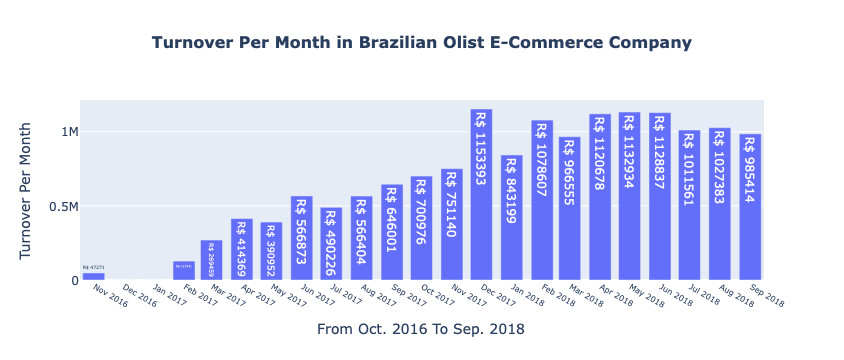

In [38]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x = merged_order_month_sum.index,
        y = merged_order_month_sum["payment_value"],
        text = merged_order_month_sum["payment_value"],
        textposition="auto",
        texttemplate="R$ %{y:.0f}"
    )
)

fig.update_layout(
    {
        "title": {
            "text": "<b>Turnover Per Month in Brazilian Olist E-Commerce Company</b>",
            "x": 0.5,
            "y": 0.9,
            "font": {
                "size": 16
            }
        },
        "xaxis": {
            "title": "From Oct. 2016 To Sep. 2018",
            "showticklabels": True,
            "dtick": "M1",
            "tickfont": {
                "size": 8
            }
        },
        "yaxis": {
            "title": "Turnover Per Month"
        }
    }
)

fig.show()

In [39]:
merged_order_month_sum_from2017 = merged_order_month_sum[merged_order_month_sum.index >= "2017-01-01"]

In [40]:
merged_order_month_sum_from2017

,payment_value
order_purchase_timestamp,
2017-01-31,127430.74
2017-02-28,269458.98
2017-03-31,414369.39
2017-04-30,390952.18
2017-05-31,566872.73
2017-06-30,490225.60
2017-07-31,566403.93
2017-08-31,646000.61
2017-09-30,700976.01


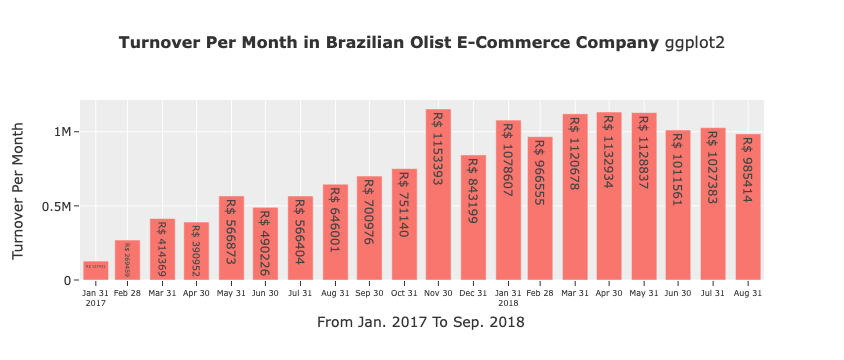

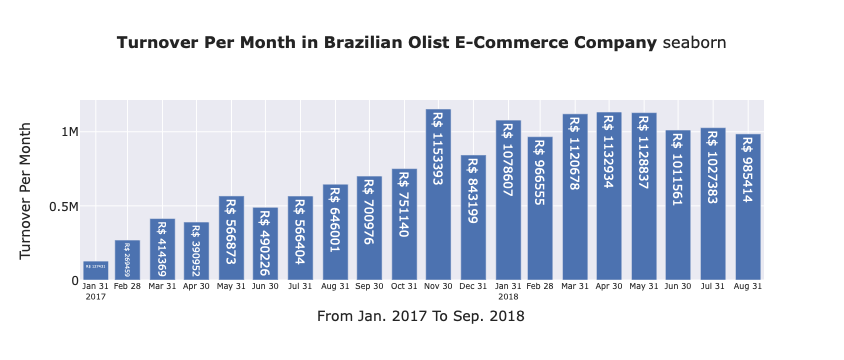

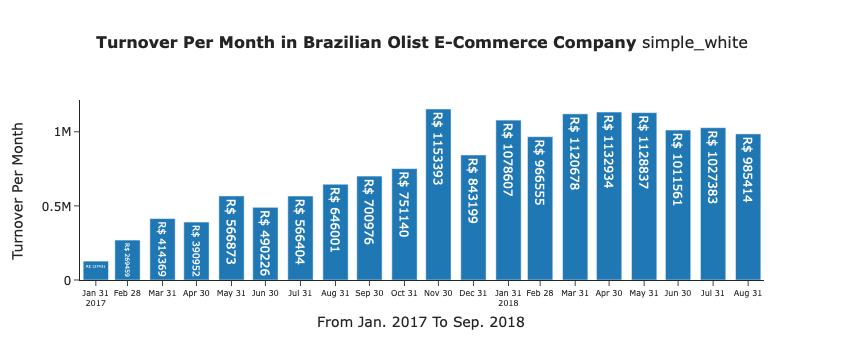

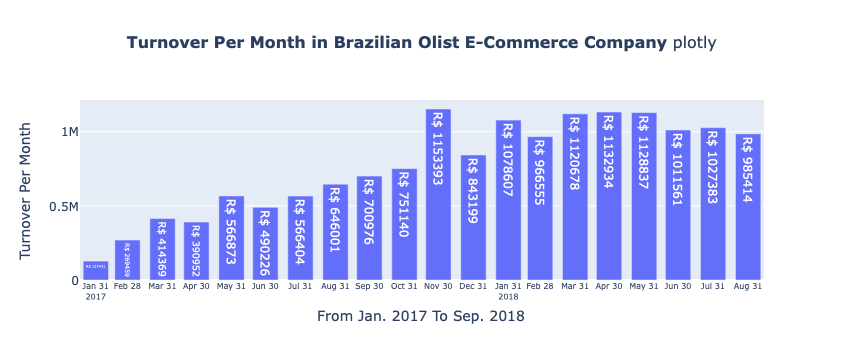

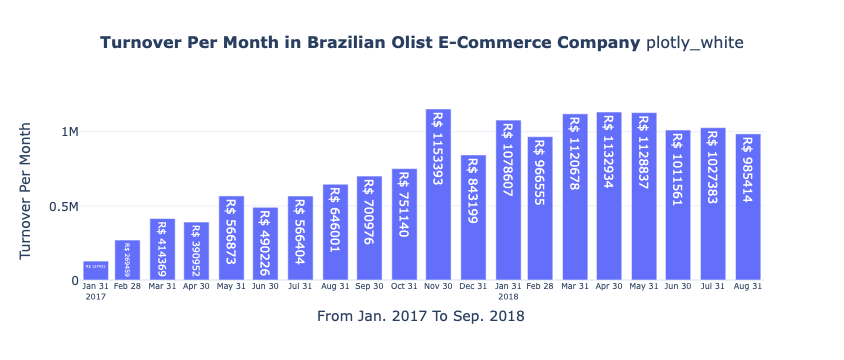

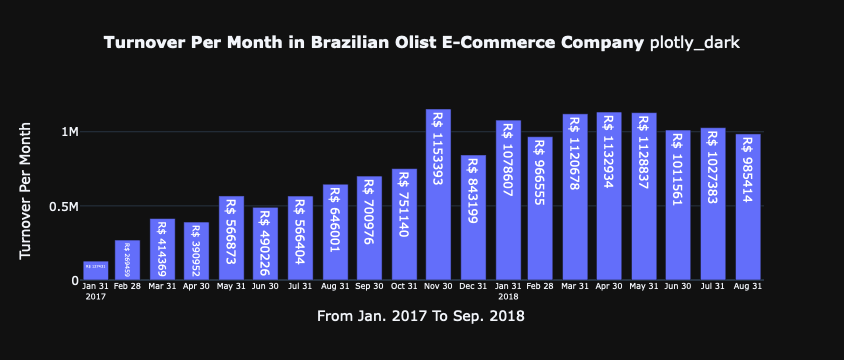

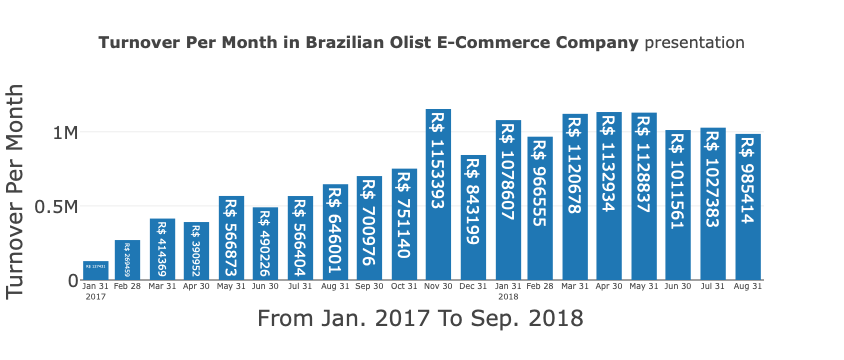

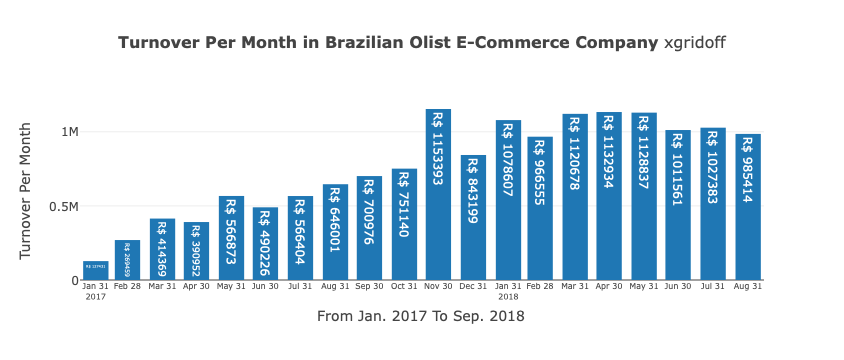

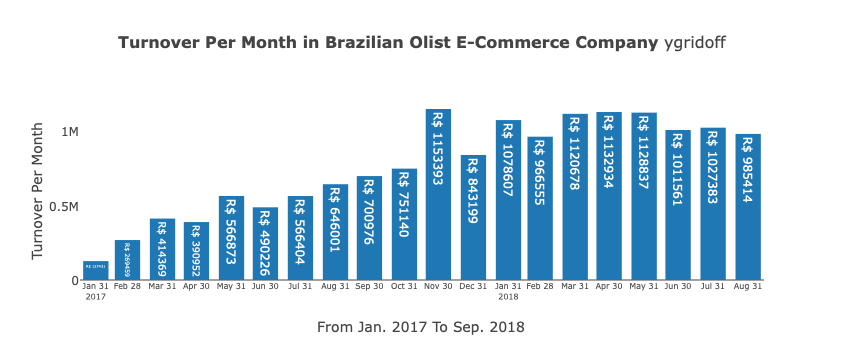

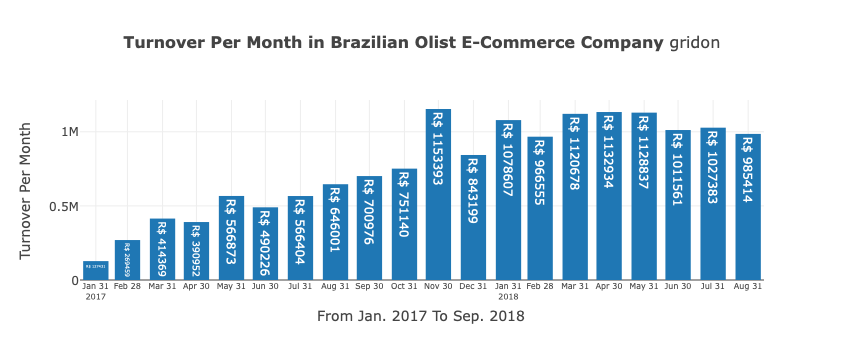

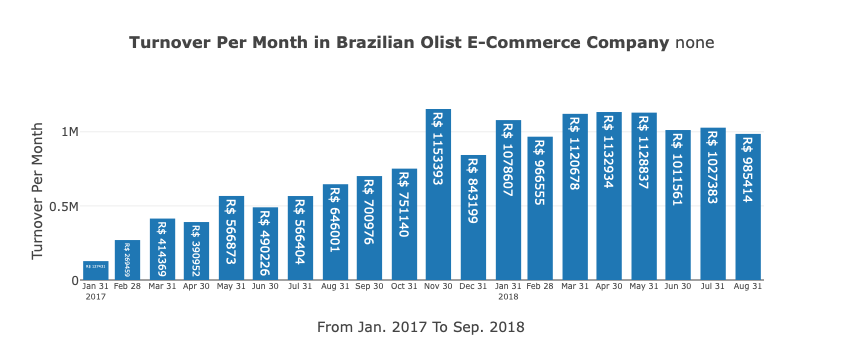

In [46]:
import plotly.graph_objects as go
import plotly.io as pio

for template in pio.templates :

    fig = go.Figure()
    
    fig.add_trace(
        go.Bar(
            x = merged_order_month_sum_from2017.index,
            y = merged_order_month_sum_from2017["payment_value"],
            text = merged_order_month_sum_from2017["payment_value"],
            textposition="auto",
            texttemplate="R$ %{y:.0f}"
        )
    )
    
    fig.update_layout(
        {
            "title": {
                "text": f"<b>Turnover Per Month in Brazilian Olist E-Commerce Company</b> {template}",
                "x": 0.5,
                "y": 0.9,
                "font": {
                    "size": 16
                }
            },
            "xaxis": {
                "title": "From Jan. 2017 To Sep. 2018",
                "showticklabels": True,
                "tick0": "2017-01-31",
                "dtick": "M1",
                "tickfont": {
                    "size": 8
                }
            },
            "yaxis": {
                "title": "Turnover Per Month"
            },
            "template": template
        }
    )

    fig.show()

In [43]:
import plotly.io as pio
pio.templates

Templates configuration
-----------------------
    Default template: 'plotly'
    Available templates:
        ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none']

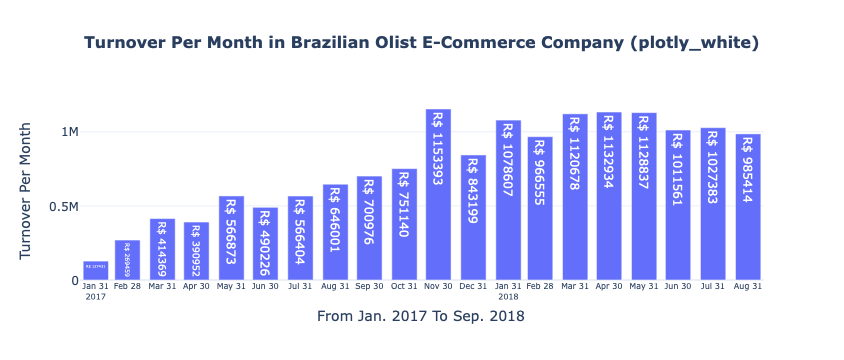

In [47]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x = merged_order_month_sum_from2017.index,
        y = merged_order_month_sum_from2017["payment_value"],
        text = merged_order_month_sum_from2017["payment_value"],
        textposition="auto",
        texttemplate="R$ %{y:.0f}"
    )
)

fig.update_layout(
    {
        "title": {
            "text": "<b>Turnover Per Month in Brazilian Olist E-Commerce Company (plotly_white)</b>",
            "x": 0.5,
            "y": 0.9,
            "font": {
                "size": 16
            }
        },
        "xaxis": {
            "title": "From Jan. 2017 To Sep. 2018",
            "showticklabels": True,
            "tick0": "2017-01-31",
            "dtick": "M1",
            "tickfont": {
                "size": 8
            }
        },
        "yaxis": {
            "title": "Turnover Per Month"
        },
        "template": "plotly_white"
    }
)

fig.show()

In [53]:
# 리스트의 곱하기 연산자의 경우, 동일한 값을 추가할 때 반드시 "," 붙여주세요!
colors = ["#03588c",] * len(merged_order_month_sum_from2017.index)
colors[10] = "#f24472"

In [54]:
colors

['#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#f24472',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c']

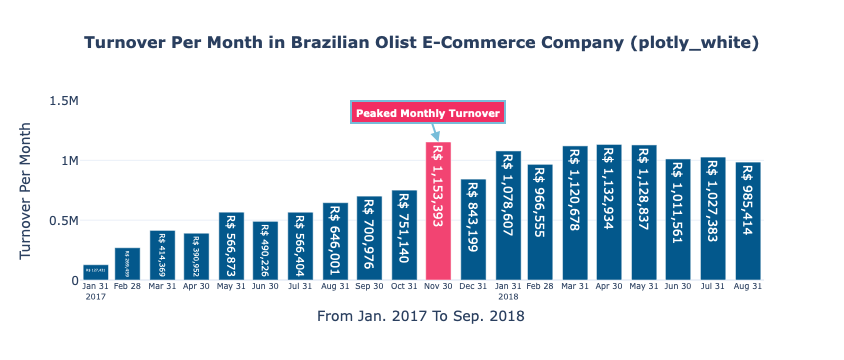

In [65]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x = merged_order_month_sum_from2017.index,
        y = merged_order_month_sum_from2017["payment_value"],
        text = merged_order_month_sum_from2017["payment_value"],
        textposition="auto",
        texttemplate="R$ %{y:,.0f}",
        marker_color=colors
    )
)

fig.update_layout(
    {
        "title": {
            "text": "<b>Turnover Per Month in Brazilian Olist E-Commerce Company (plotly_white)</b>",
            "x": 0.5,
            "y": 0.9,
            "font": {
                "size": 16
            }
        },
        "xaxis": {
            "title": "From Jan. 2017 To Sep. 2018",
            "showticklabels": True,
            "tick0": "2017-01-31",
            "dtick": "M1",
            "tickfont": {
                "size": 8
            }
        },
        "yaxis": {
            "title": "Turnover Per Month"
        },
        "template": "plotly_white"
    }
)

fig.add_annotation(
    x = "2017-11-30",
    y = 1153393,
    text = "<b>Peaked Monthly Turnover</b>",
    showarrow = True,
    arrowhead = 2,
    arrowsize = 1,
    arrowwidth = 2,
    arrowcolor = "#77bdd9",
    font = {
        "size": 10,
        "color": "#ffffff"
    },
    bgcolor = "#f22e62",
    bordercolor = "#77bdd9",
    borderwidth = 2,
    borderpad = 4,
    align = "center"
)

fig.show()